In [55]:
import warnings
import datetime
from time import time
import pandas as pd
import os, cv2, math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.listdir('.')

['nightSequence1',
 'Annotations',
 'Analisys.ipynb',
 'sample-nightClip1',
 'nightTrain',
 'nightSequence2',
 'daySequence2',
 'dayTrain',
 'sample-dayClip6',
 'daySequence1']

In [56]:
DAY_TRAIN_PATH = 'Annotations/Annotations/dayTrain/'
NIGHT_TRAIN_PATH = 'Annotations/Annotations/nightTrain/'

day = []
for clipName in tqdm(sorted(os.listdir(DAY_TRAIN_PATH))):
    if 'dayClip' not in clipName:
        continue
    df = pd.read_csv(os.path.join(DAY_TRAIN_PATH,clipName,'frameAnnotationsBOX.csv'),sep=';')
    day.append(df)
    
day_df = pd.concat(day,axis=0)
day_df['isNight'] = 0

night = []
for clipName in tqdm(sorted(os.listdir(NIGHT_TRAIN_PATH))):
    if 'nightClip' not in clipName:
        continue
    df = pd.read_csv(os.path.join(NIGHT_TRAIN_PATH,clipName,'frameAnnotationsBOX.csv'),sep=';')
    night.append(df)

night_df = pd.concat(night,axis=0)
night_df['isNight'] = 1

df = pd.concat([day_df, night_df],axis=0)
df

100%|██████████| 5/5 [00:00<00:00, 392.42it/s]


,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number,isNight
0,dayTraining/dayClip1--00000.jpg,go,698,333,710,358,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,0
1,dayTraining/dayClip1--00000.jpg,go,846,391,858,411,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,0
2,dayTraining/dayClip1--00001.jpg,go,698,337,710,357,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,0
3,dayTraining/dayClip1--00001.jpg,go,847,390,859,410,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,0
4,dayTraining/dayClip1--00002.jpg,go,698,331,710,356,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,2,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,2,0
...,...,...,...,...,...,...,...,...,...,...,...
3231,nightTraining/nightClip5--01450.jpg,go,937,221,976,290,nightTraining/nightClip5/clip5.mp4,1450,nightTraining/nightClip5/clip5.mp4,1450,1
3232,nightTraining/nightClip5--01451.jpg,go,467,36,512,117,nightTraining/nightClip5/clip5.mp4,1451,nightTraining/nightClip5/clip5.mp4,1451,1
3233,nightTraining/nightClip5--01451.jpg,go,937,219,976,288,nightTraining/nightClip5/clip5.mp4,1451,nightTraining/nightClip5/clip5.mp4,1451,1
3234,nightTraining/nightClip5--01452.jpg,go,460,33,506,114,nightTraining/nightClip5/clip5.mp4,1452,nightTraining/nightClip5/clip5.mp4,1452,1


- Duplicate Columns

In [57]:
np.all(df['Origin file'] == df['Origin track']), np.all(df['Origin frame number'] == df['Origin track frame number'])

(np.True_, np.True_)

- Droppin duplicate columns & "Origin file" as we don't need it

In [58]:
df = df.drop(['Origin file','Origin track','Origin track frame number'],axis=1)

In [59]:
def changeFilename(x):
    splitted = x.Filename.split('/')
    clipName = splitted[-1].split('--')[0]

    if x.isNight:
        return f'nightTrain/nightTrain/{clipName}/frames/{splitted[-1]}'
    
    return f'dayTrain/dayTrain/{clipName}/frames/{splitted[-1]}'


df['Filename'] = df.apply(changeFilename,axis=1)
df.columns     = ['path','label','x_min','y_min','x_max','y_max','frame','isNight']
df

,path,label,x_min,y_min,x_max,y_max,frame,isNight
0,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,698,333,710,358,0,0
1,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,846,391,858,411,0,0
2,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,698,337,710,357,1,0
3,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,847,390,859,410,1,0
4,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,698,331,710,356,2,0
...,...,...,...,...,...,...,...,...
3231,nightTrain/nightTrain/nightClip5/frames/nightC...,go,937,221,976,290,1450,1
3232,nightTrain/nightTrain/nightClip5/frames/nightC...,go,467,36,512,117,1451,1
3233,nightTrain/nightTrain/nightClip5/frames/nightC...,go,937,219,976,288,1451,1
3234,nightTrain/nightTrain/nightClip5/frames/nightC...,go,460,33,506,114,1452,1


In [60]:
df.label.unique()

array(['go', 'stop', 'stopLeft', 'warning', 'goLeft', 'warningLeft'],
      dtype=object)

In [61]:
class_names = {'go': 1, 'warning': 2, 'stop': 3}
df['value'] = 0

df.loc[df.label.str.contains('go',      na=False), 'label'] = 'go'
df.loc[df.label.str.contains('warning', na=False), 'label'] = 'warning'
df.loc[df.label.str.contains('stop',    na=False), 'label'] = 'stop'

df.loc[df.label == 'go',      'value'] = class_names['go']
df.loc[df.label == 'warning', 'value'] = class_names['warning']
df.loc[df.label == 'stop',    'value'] = class_names['stop']

print(df.label.unique())
print(df.value.unique())
df.head()

['go' 'stop' 'warning']
[1 3 2]


,path,label,x_min,y_min,x_max,y_max,frame,isNight,value
0,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,698,333,710,358,0,0,1
1,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,846,391,858,411,0,0,1
2,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,698,337,710,357,1,0,1
3,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,847,390,859,410,1,0,1
4,dayTrain/dayTrain/dayClip1/frames/dayClip1--00...,go,698,331,710,356,2,0,1


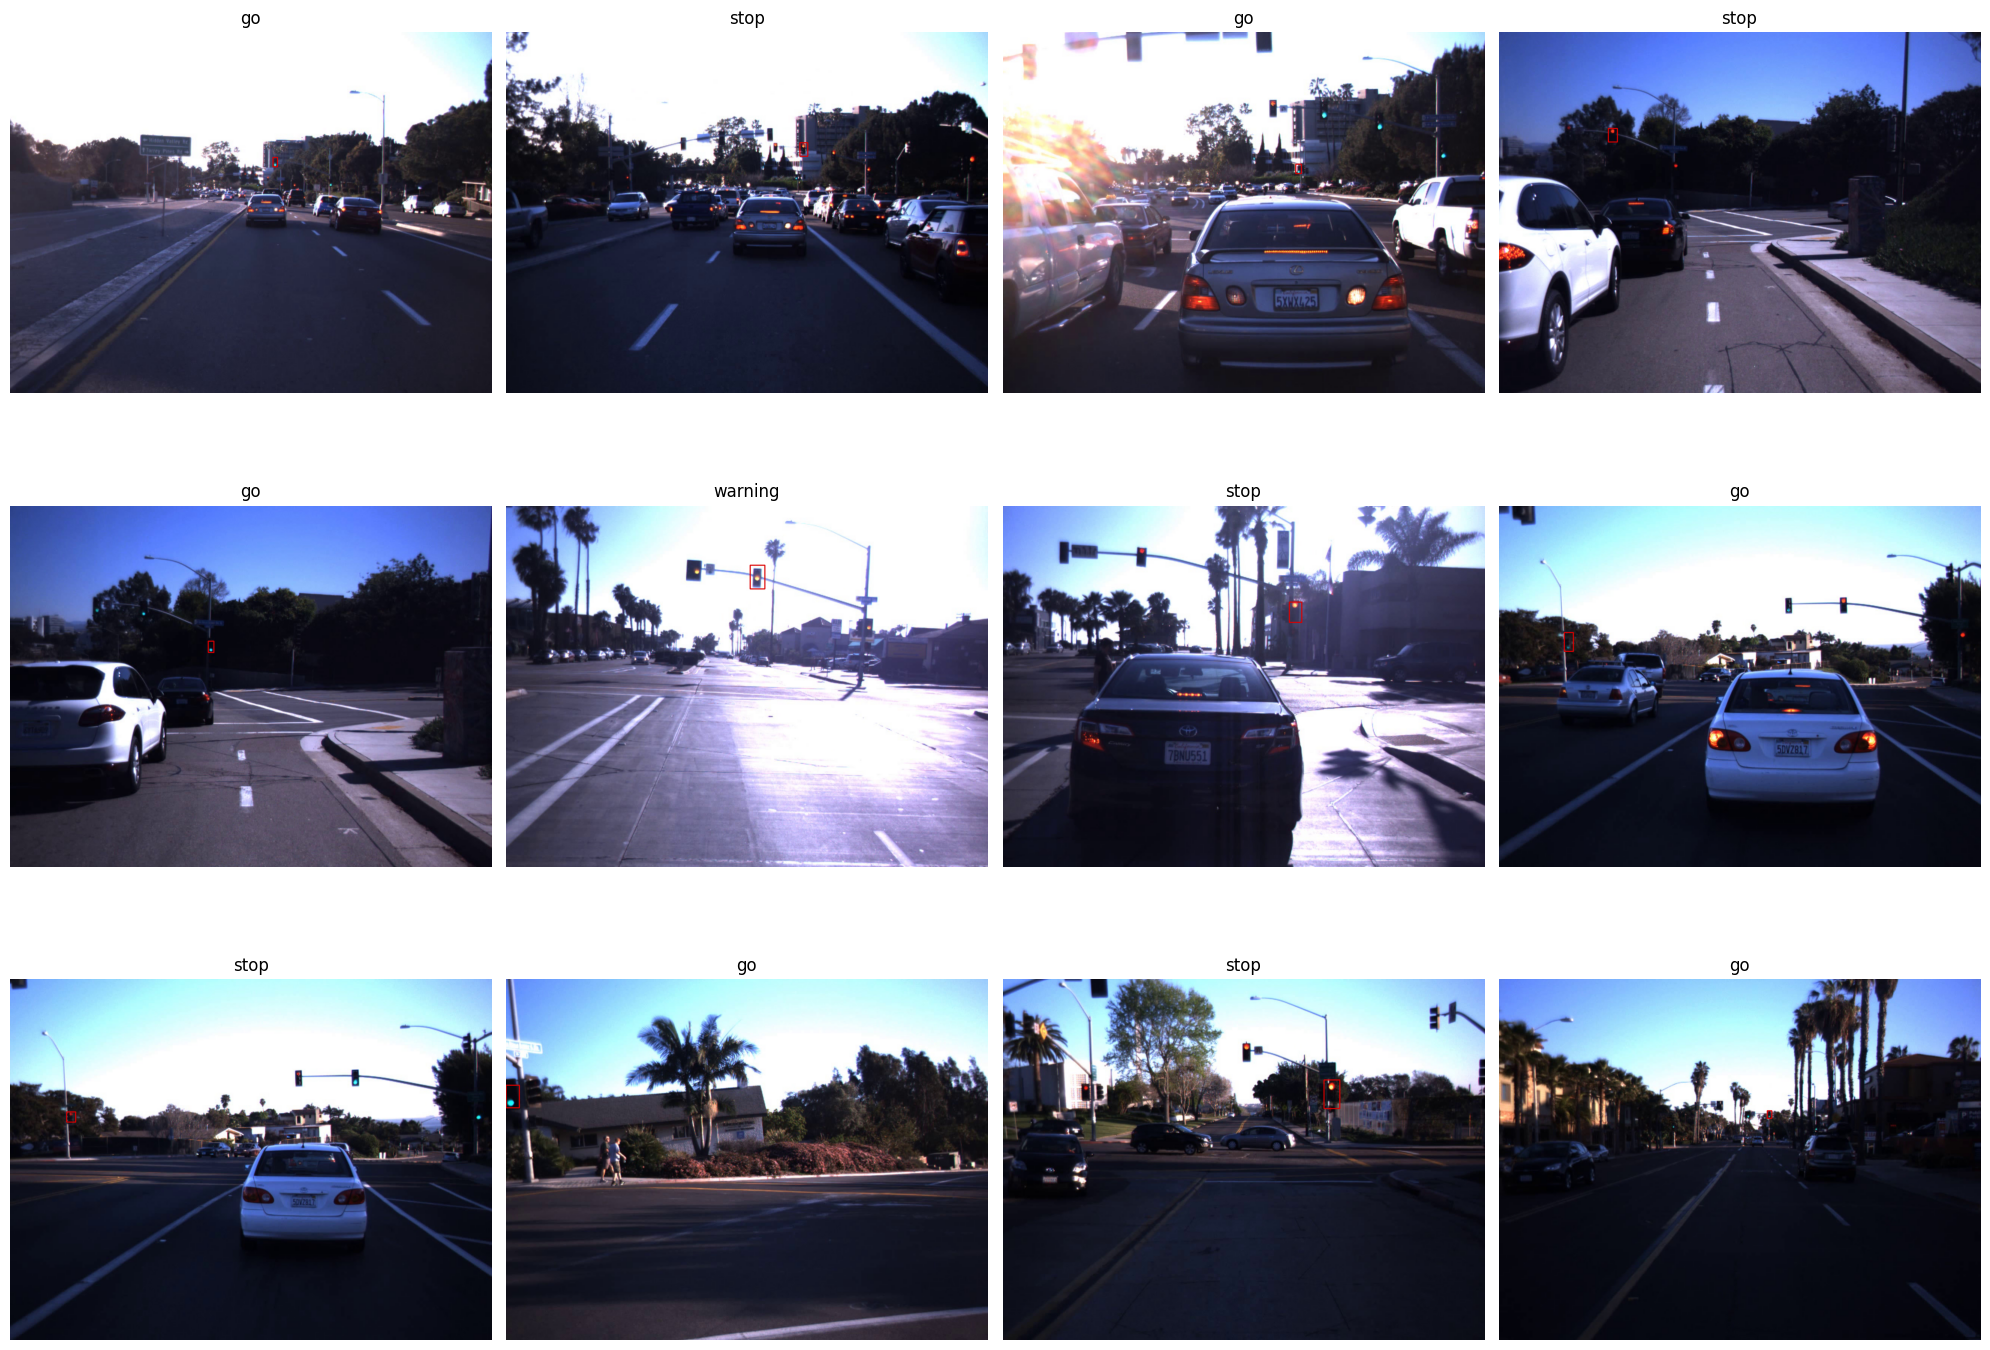

In [62]:
def plotTables(df, limit=None):
    count   = len(df) if limit is None else min(limit, len(df))
    numCols = 4 if count >= 4 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(5*numCols, 5*numRows))
    index = 0
    lastLabel = None
    
    for i, row in df[::500].iterrows():
        if index >= count:
            break

        if lastLabel == row.label:
            continue
        
        img = cv2.imread(row.path, cv2.IMREAD_COLOR_RGB)
        lastLabel = row.label
        index     = index + 1

        plt.subplot(numRows, numCols, index)
        cv2.rectangle(img, (row.x_min, row.y_min), (row.x_max, row.y_max), 220, 2)
        plt.title(row.label)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


plotTables(df, 12)

In [ ]:
os.makedirs('../Model/Database', exist_ok=True)
df.to_csv('../Model/database/DataBase.csv', index=None)